# Predict Oral Cancer from New Image

Run the cell below to load your trained model and evaluate an image for cancer. Ensure the `test_image` path is pointed to the image you want to test before running.

Ensure your model 'improved_oral_cancer_model.keras' is fully trained before predicting!
Loading improved_oral_cancer_model.keras...
Processing C:\Users\venun\OneDrive\Desktop\PAD\OralCancer\NON CANCER\20191129_1750382.jpg...

Result: Non-Cancer
Confidence: 51.50% (raw score: 0.5150)
Saved visual to result_20191129_1750382.jpg



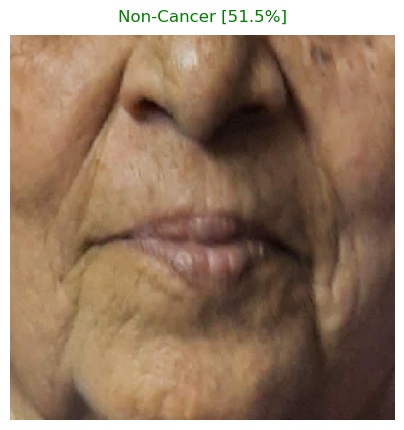

In [4]:
import os
import sys
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Default model name we trained earlier
MODEL_NAME = 'improved_oral_cancer_model.keras'

def load_prediction_model():
    if not os.path.exists(MODEL_NAME):
        print(f"Error: Could not find {MODEL_NAME} in the current directory.")
        print("Did you finish running 'Improved Model.ipynb' first?")
        sys.exit(1)
        
    print(f"Loading {MODEL_NAME}...")
    return tf.keras.models.load_model(MODEL_NAME)

def predict_single_image(model, img_path):
    if not os.path.exists(img_path):
        print(f"Error: Image '{img_path}' not found.")
        return

    print(f"Processing {img_path}...")
    
    # Load and prep the image exactly like the training data generator did
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0  # normalize

    # Get the raw prediction
    pred = model.predict(img_array, verbose=0)[0][0]

    # Map the output back to our binary classes
    if pred < 0.5:
        result_class = "Cancer"
        confidence = (1 - pred) * 100
        color = 'red'
    else:
        result_class = "Non-Cancer"
        confidence = pred * 100
        color = 'green'

    print(f"\nResult: {result_class}")
    print(f"Confidence: {confidence:.2f}% (raw score: {pred:.4f})")

    # Show the image visually
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"{result_class} [{confidence:.1f}%]", color=color, pad=10)
    plt.axis('off')
    
    # Save it out so we have proof
    save_name = f"result_{os.path.basename(img_path)}"
    plt.savefig(save_name, bbox_inches='tight')
    print(f"Saved visual to {save_name}\n")
    plt.show() # Automatically show the pop-up graph inside the notebook


print("Ensure your model 'improved_oral_cancer_model.keras' is fully trained before predicting!")
test_image = r"C:\Users\venun\OneDrive\Desktop\PAD\OralCancer\NON CANCER\20191129_1750382.jpg"

model = load_prediction_model()
predict_single_image(model, test_image)
